In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler,LabelEncoder, PolynomialFeatures
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [111]:
df=pd.read_csv('/content/zomato.csv', engine='python', on_bad_lines='warn')
df.head()

/tmp/ipykernel_14390/3352973330.py:1: ParserWarning: Skipping line 1130: field larger than field limit (131072)

  df=pd.read_csv('/content/zomato.csv', engine='python', on_bad_lines='warn')
/tmp/ipykernel_14390/3352973330.py:1: ParserWarning: Skipping line 2046: field larger than field limit (131072)

  df=pd.read_csv('/content/zomato.csv', engine='python', on_bad_lines='warn')
/tmp/ipykernel_14390/3352973330.py:1: ParserWarning: Skipping line 2588: field larger than field limit (131072)

  df=pd.read_csv('/content/zomato.csv', engine='python', on_bad_lines='warn')
/tmp/ipykernel_14390/3352973330.py:1: ParserWarning: Skipping line 4133: field larger than field limit (131072)

  df=pd.read_csv('/content/zomato.csv', engine='python', on_bad_lines='warn')
/tmp/ipykernel_14390/3352973330.py:1: ParserWarning: Skipping line 4244: field larger than field limit (131072)

  df=pd.read_csv('/content/zomato.csv', engine='python', on_bad_lines='warn')
/tmp/ipykernel_14390/3352973330.py:1: ParserW

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [112]:
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [113]:
df.columns,df.shape

(Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
        'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
        'approx_cost(for two people)', 'reviews_list', 'menu_item',
        'listed_in(type)', 'listed_in(city)'],
       dtype='object'),
 (51155, 17))

In [114]:
df.info()
# dataset doesnot contain any null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51155 entries, 0 to 51154
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51155 non-null  object
 1   address                      51155 non-null  object
 2   name                         51155 non-null  object
 3   online_order                 51155 non-null  object
 4   book_table                   51155 non-null  object
 5   rate                         43380 non-null  object
 6   votes                        51155 non-null  int64 
 7   phone                        49952 non-null  object
 8   location                     51134 non-null  object
 9   rest_type                    50931 non-null  object
 10  dish_liked                   23081 non-null  object
 11  cuisines                     51110 non-null  object
 12  approx_cost(for two people)  50811 non-null  object
 13  reviews_list                 51

# Data preprocessing

### Column Renaming
* Simplifuing column names for easier access

In [115]:
# Rename column
df.rename(columns={'approx_cost(for two people)': 'CostFor2', 'listed(city)':'city' , 'listed_in(type)':'type'} , inplace=True)

* Cleaniong columns

In [116]:
# clearing the columns i.e, rplace the empty string in "menu_item" column with NaN
df['menu_item'].replace('[]',np.nan,inplace=True)

/tmp/ipykernel_14390/1552112096.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['menu_item'].replace('[]',np.nan,inplace=True)


In [117]:
# finding the missing values
(df.isnull().sum()/df.shape[0])*100
# this gives the percentage of the null values in each column

,0
url,0.000000
address,0.000000
name,0.000000
online_order,0.000000
book_table,0.000000
rate,15.198905
votes,0.000000
phone,2.351676
location,0.041052
rest_type,0.437885


In [118]:
# Drop the column that have more than 50% null values
df.drop(columns=['menu_item','dish_liked'],inplace=True)


In [119]:
df.shape

(51155, 15)

# Feature Engineering

In [120]:
df['reviews_list'][0]

'[(\'Rated 4.0\', \'RATED\\n  A beautiful place to dine in.The interiors take you back to the Mughal era. The lightings are just perfect.We went there on the occasion of Christmas and so they had only limited items available. But the taste and service was not compromised at all.The only complaint is that the breads could have been better.Would surely like to come here again.\'), (\'Rated 4.0\', \'RATED\\n  I was here for dinner with my family on a weekday. The restaurant was completely empty. Ambience is good with some good old hindi music. Seating arrangement are good too. We ordered masala papad, panner and baby corn starters, lemon and corrionder soup, butter roti, olive and chilli paratha. Food was fresh and good, service is good too. Good for family hangout.\\nCheers\'), (\'Rated 2.0\', \'RATED\\n  Its a restaurant near to Banashankari BDA. Me along with few of my office friends visited to have buffet but unfortunately they only provide veg buffet. On inquiring they said this plac

In [121]:
# Fetch number of reviews for each restuarent out of the 'review_list' column
def review_count(l):
  return len(l)

df['reviews_count'] =df['reviews_list'].apply(review_count)

### Data cleaning - "Rating" column
 * converting rating strings to numeric values and handling missing values

In [122]:
df['rate'].unique()

# clean the "rate" column
df['rate'].replace('NEW',np.nan,inplace=True)
df['rate'].replace('-',np.nan,inplace=True)

# Fill the Null values with mode pf the column
df.fillna(df['rate'].mode()[0], inplace =True)


# convert the 'rate' to numeric values
def clean_rate(x):
  return float(x.split('/')[0])

df['rate'] = df['rate'].apply(clean_rate)

/tmp/ipykernel_14390/1606866379.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rate'].replace('NEW',np.nan,inplace=True)
/tmp/ipykernel_14390/1606866379.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [123]:
df['rate'].unique()

array([4.1, 3.8, 3.7, 3.6, 4.6, 4. , 4.2, 3.9, 3.1, 3. , 3.2, 3.3, 2.8,
       4.4, 4.3, 2.9, 3.5, 2.6, 3.4, 4.5, 2.5, 2.7, 4.7, 2.4, 2.2, 2.3,
       4.8, 4.9, 2.1, 2. , 1.8])

### Data cleaning - "Cost column"
*

In [124]:
# Display unique values of 'CostFor2' column
df["CostFor2"].unique()

# Clean the 'CostFor2' column by removing commas and converting into float
# Handle non-numeric strings by converting them to NaN
def clean_cost(x):
    if isinstance(x, str):
        x = x.replace(",", "")
        try:
            return float(x)
        except ValueError:
            return np.nan
    return x # For values that are already numeric or NaN

df["CostFor2"] = df["CostFor2"].apply(clean_cost)

# Fill NaN values in 'CostFor2' with the mode of the *cleaned* column
df["CostFor2"] = df["CostFor2"].fillna(df["CostFor2"].mode()[0])

In [125]:
df["CostFor2"].unique()

array([ 800.,  300.,  600.,  700.,  550.,  500.,  450.,  650.,  400.,
        900.,  200.,  750.,  150.,  850.,  100., 1200.,  350.,  250.,
        950., 1000., 1500., 1300.,  199.,   80., 1100.,  160., 1600.,
        230.,  130.,   50.,  190., 1700., 1400.,  180., 1350., 2200.,
       2000., 1800., 1900.,  330., 2500., 2100., 3000., 2800., 3400.,
         40., 1250., 3500., 4000., 2400., 2600.,  120., 1450.,  469.,
         70., 3200.,   60.,  560.,  240.,  360., 6000., 1050., 2300.,
       4100., 5000., 3700., 1650., 2700., 4500.,  140.])

### Dropping the unneccessary column

In [126]:
df.drop(['url','address','phone','reviews_list','listed_in(city)'],axis=1,inplace=True)

In [127]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'location',
       'rest_type', 'cuisines', 'CostFor2', 'type', 'reviews_count'],
      dtype='object')

In [128]:
# drop rows with NaN values
df.dropna(inplace=True)

# drop duplicate rows
df.drop_duplicates(inplace=True)

# display the shape of the cleaned dataset
df.shape,df.head(5)

((36381, 11),
                     name online_order book_table  rate  votes      location  \
 0                  Jalsa          Yes        Yes   4.1    775  Banashankari   
 1         Spice Elephant          Yes         No   4.1    787  Banashankari   
 2        San Churro Cafe          Yes         No   3.8    918  Banashankari   
 3  Addhuri Udupi Bhojana           No         No   3.7     88  Banashankari   
 4          Grand Village           No         No   3.8    166  Basavanagudi   
 
              rest_type                        cuisines  CostFor2    type  \
 0        Casual Dining  North Indian, Mughlai, Chinese     800.0  Buffet   
 1        Casual Dining     Chinese, North Indian, Thai     800.0  Buffet   
 2  Cafe, Casual Dining          Cafe, Mexican, Italian     800.0  Buffet   
 3          Quick Bites      South Indian, North Indian     300.0  Buffet   
 4        Casual Dining        North Indian, Rajasthani     600.0  Buffet   
 
    reviews_count  
 0           3955  


In [129]:
df.isnull().sum()

,0
name,0
online_order,0
book_table,0
rate,0
votes,0
location,0
rest_type,0
cuisines,0
CostFor2,0
type,0


### Categorical Data processing

In [130]:
# Fetch the most frequent values (10 values) for 'rest_type' ,'cuisines' , and 'location'
most_freq_rest_type=df['rest_type'].value_counts().nlargest(10)
most_freq_cuisiness=df['cuisines'].value_counts().nlargest(15)
most_freq_location=df['location'].value_counts().nlargest(10)
# it shows that most order comes from the BTM and most cuisiness is the North Indian and most preferred is the quick bites

# Replace the less freq values in 'rest_type' ,'cuisines' , and 'location' with "Other"
df['rest_type']=df['rest_type'].apply(lambda x: x if x in most_freq_rest_type.index else 'Other')
df['cuisines']=df['cuisines'].apply(lambda x: x if x in most_freq_cuisiness.index else 'Other')
df['location']=df['location'].apply(lambda x: x if x in most_freq_location.index else 'Other')

In [131]:
# Reset the index of the dataet
df.reset_index(drop=True , inplace=True)
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,CostFor2,type,reviews_count
0,Jalsa,Yes,Yes,4.1,775,Other,Casual Dining,Other,800.0,Buffet,3955
1,Spice Elephant,Yes,No,4.1,787,Other,Casual Dining,Other,800.0,Buffet,5256
2,San Churro Cafe,Yes,No,3.8,918,Other,Other,Other,800.0,Buffet,7549
3,Addhuri Udupi Bhojana,No,No,3.7,88,Other,Quick Bites,Other,300.0,Buffet,14876
4,Grand Village,No,No,3.8,166,Other,Casual Dining,Other,600.0,Buffet,702


# EDA

### 1) Online order Distribution

Text(0, 0.5, 'Frequency')

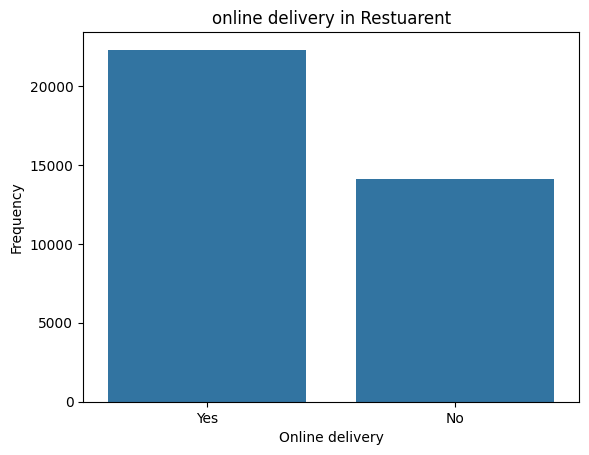

In [132]:
#
sns.countplot( data=df,x='online_order')
plt.title('online delivery in Restuarent')
plt.xlabel('Online delivery')
plt.ylabel('Frequency')

### 2)Table booking distribution

Text(0, 0.5, 'Frequency')

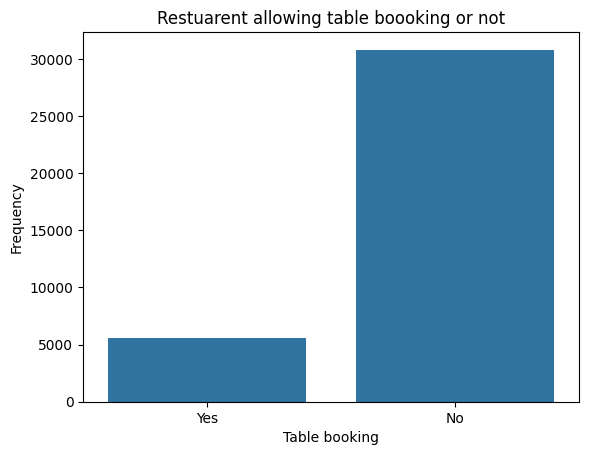

In [133]:
sns.countplot(data=df,x='book_table')
plt.title('Restuarent allowing table boooking or not')
plt.xlabel('Table booking')
plt.ylabel('Frequency')

### 3) Location vs rating Analysis

Text(0, 0.5, 'Rating')

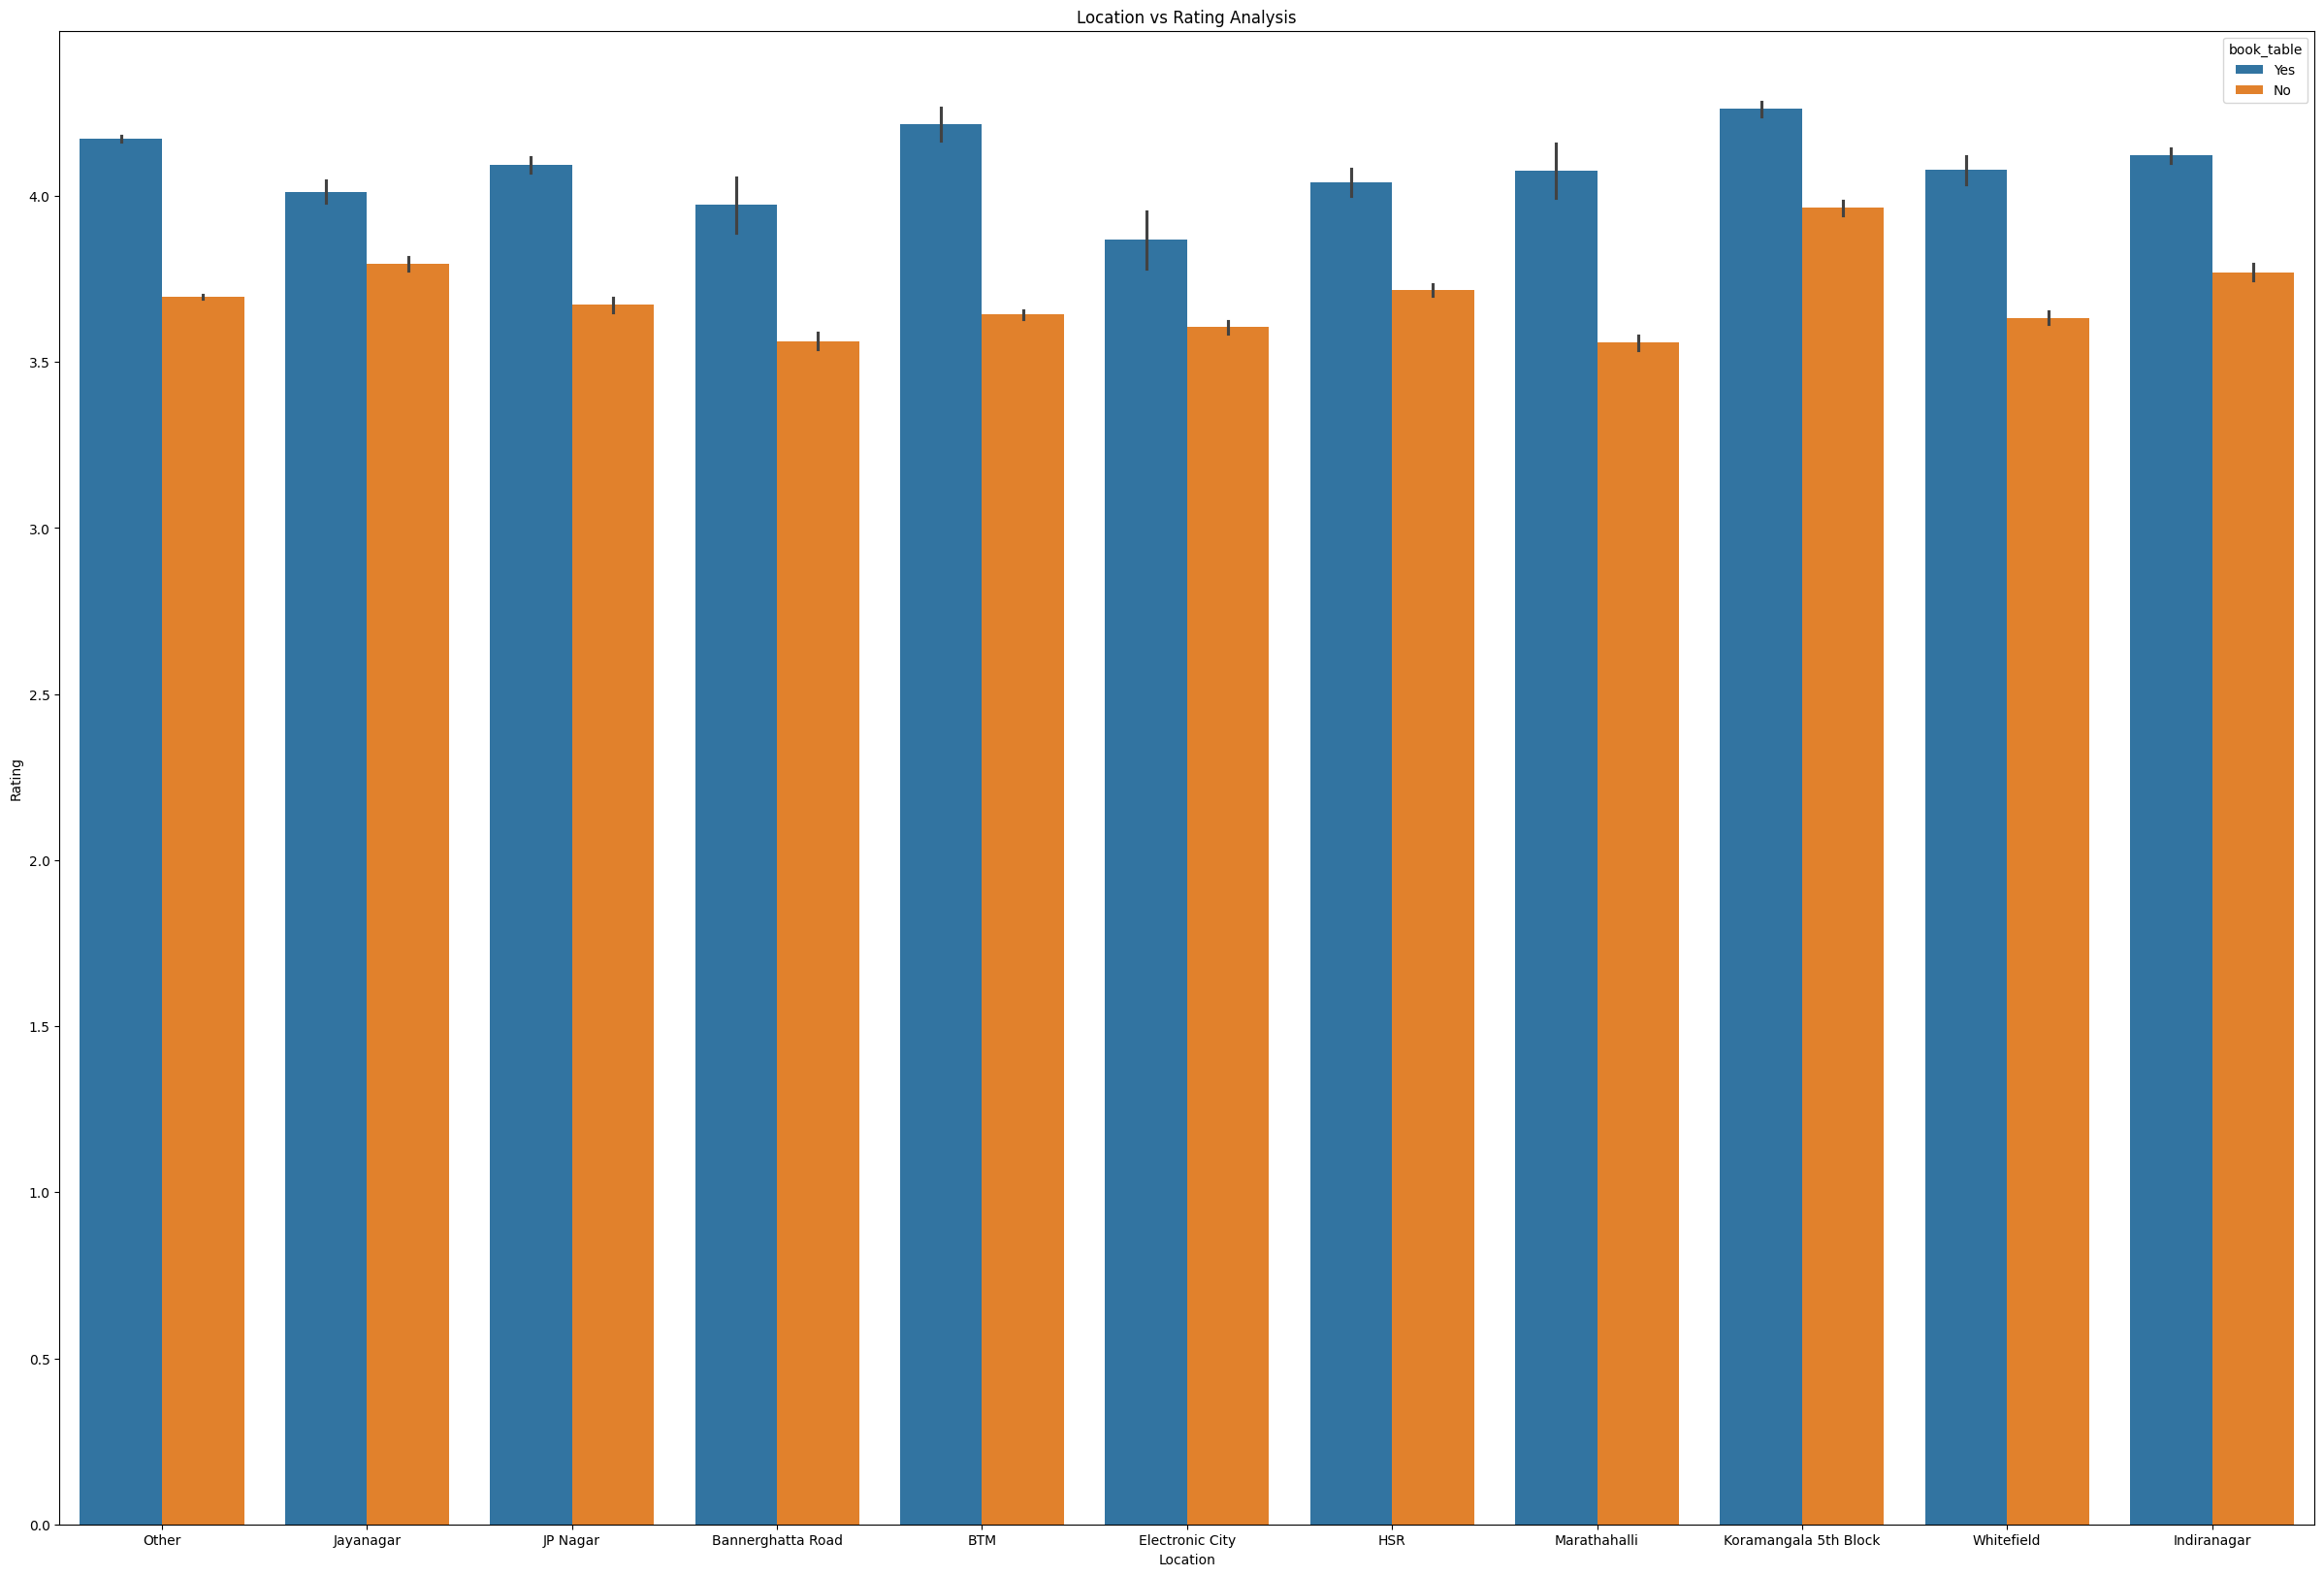

In [134]:
# Analysis of the relationship between location , rating and table booking avalibility u

plt.figure(figsize=(30,20))
sns.barplot(data=df,x='location',y='rate', hue='book_table')
plt.title('Location vs Rating Analysis')
plt.xlabel('Location')
plt.ylabel('Rating')

### 4) Best Rated Locations

Text(0, 0.5, 'Rating')

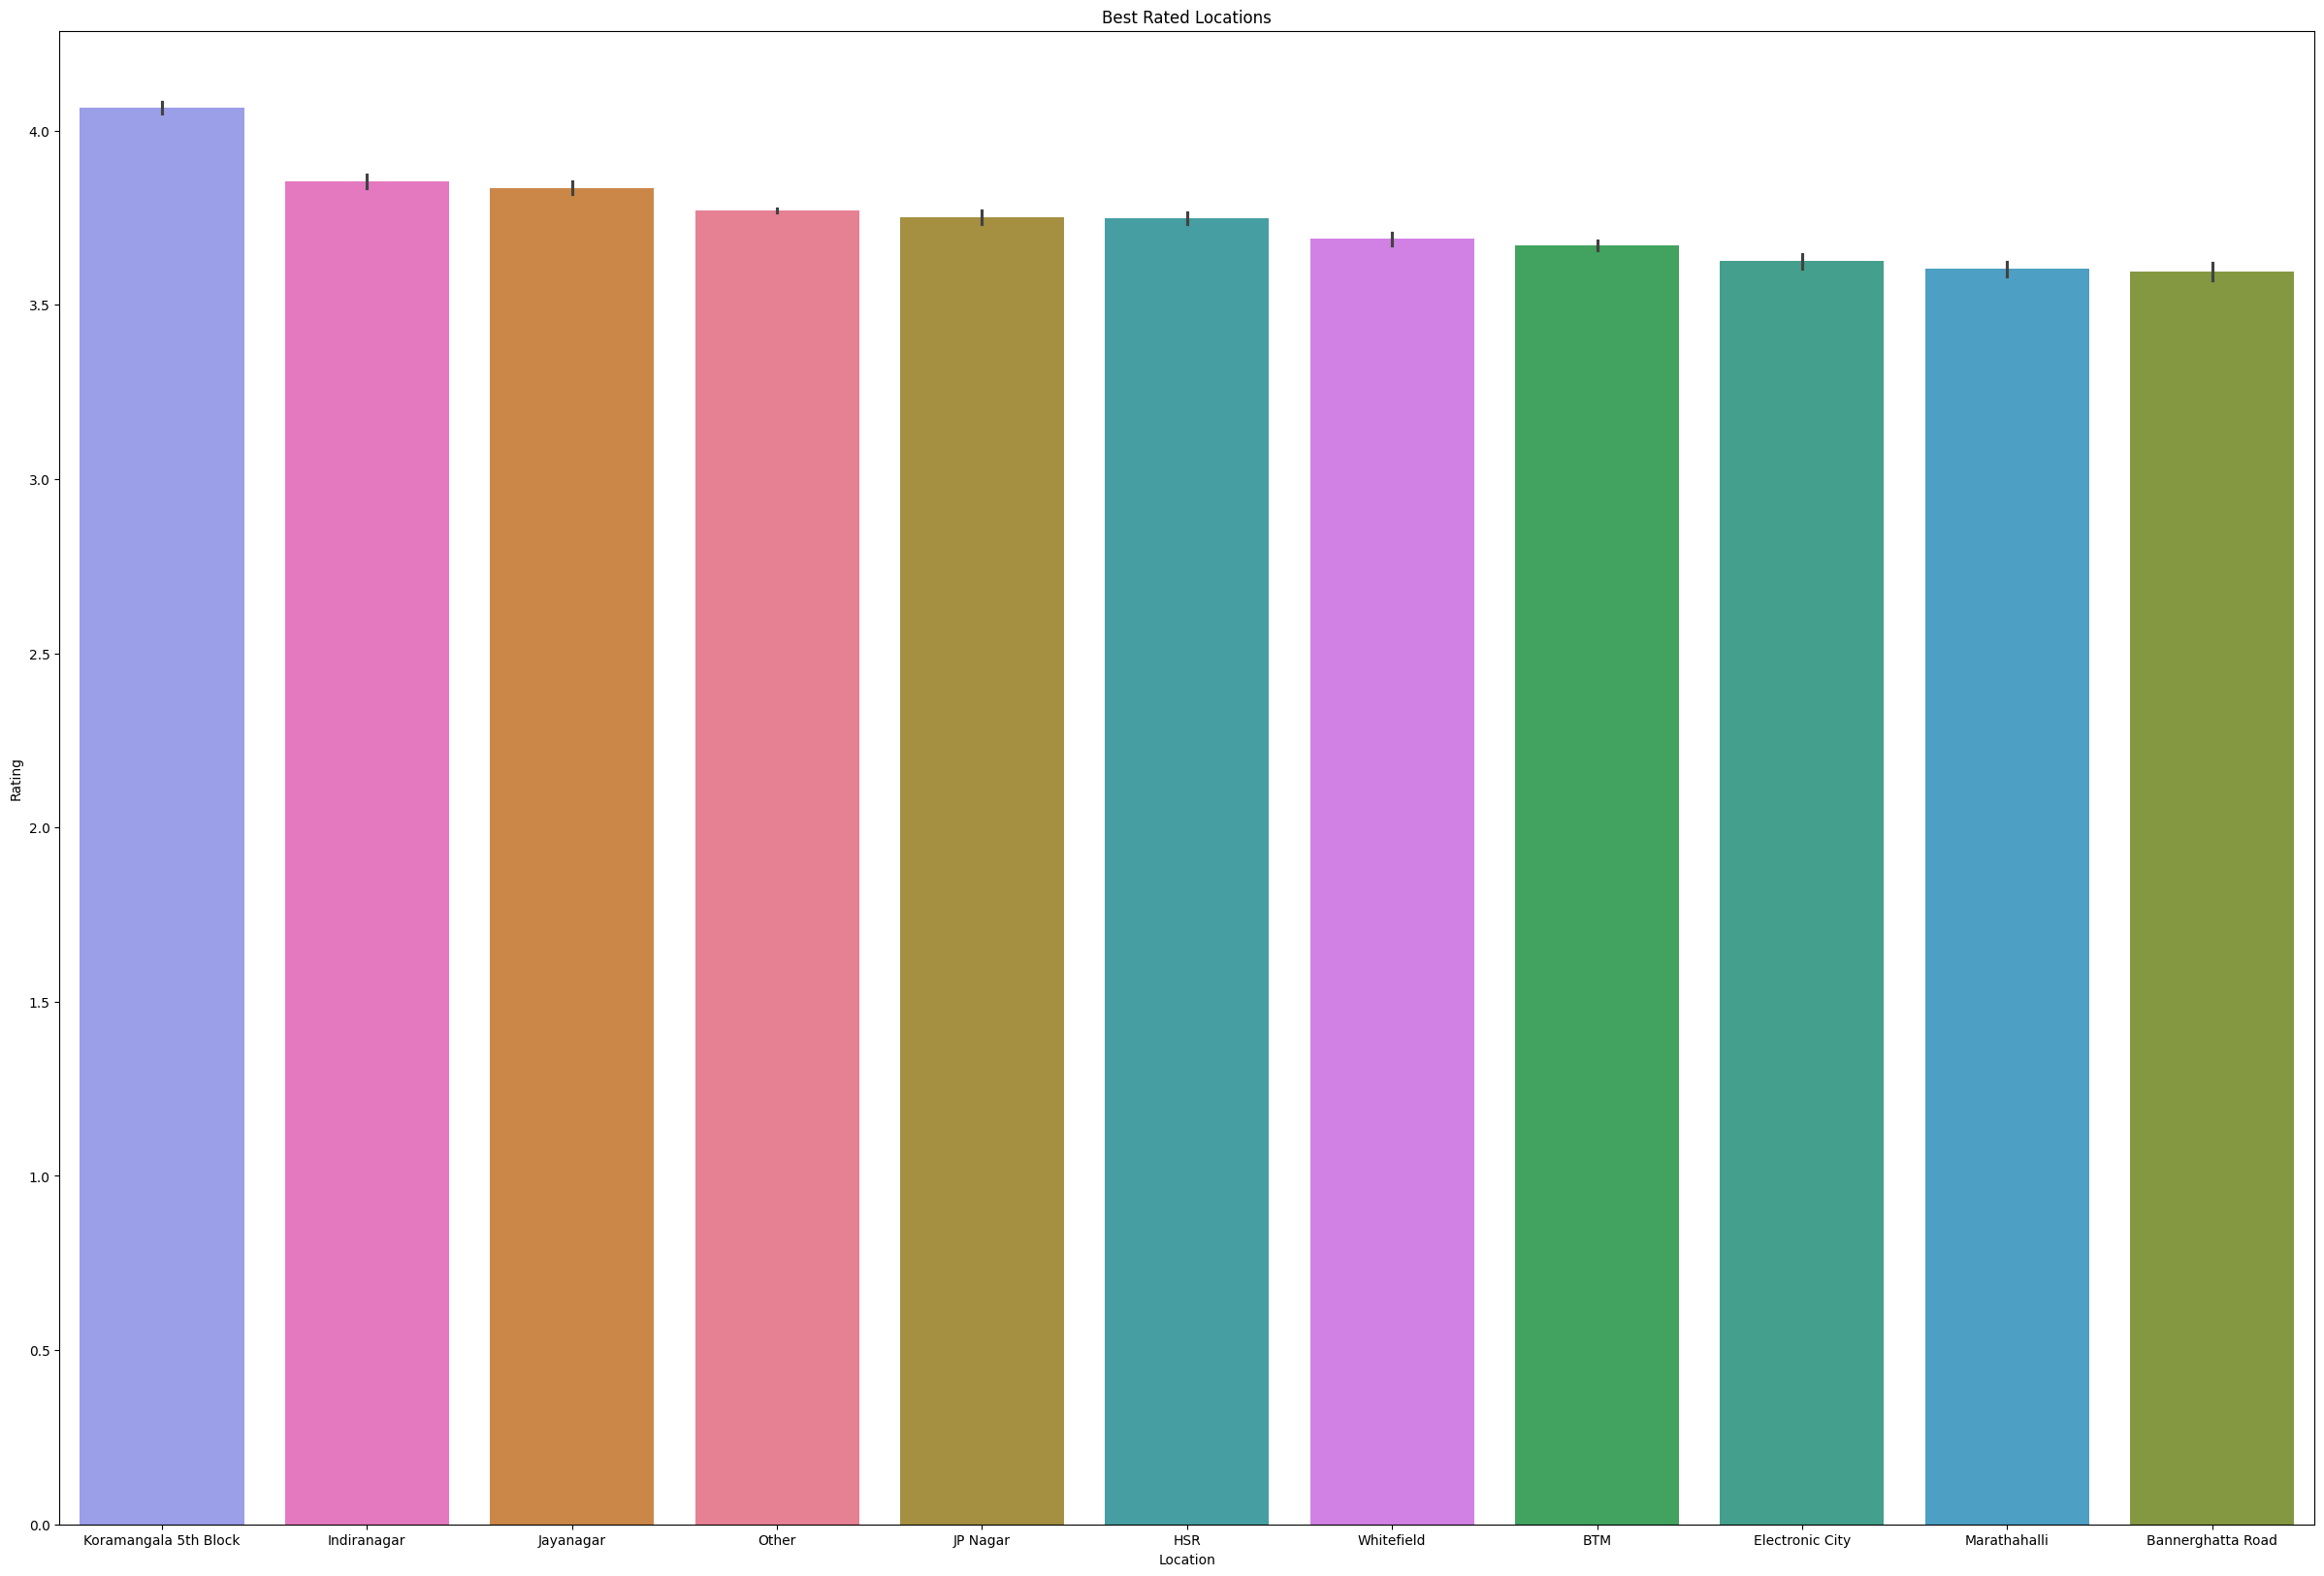

In [135]:
plt.figure(figsize=(30,20))

location_order = df.groupby('location')['rate'].mean().sort_values(ascending=False).index

sns.barplot(data=df, x='location', y='rate', order=location_order, hue='location', legend=False)

plt.title('Best Rated Locations')
plt.xlabel('Location')
plt.ylabel('Rating')


### 5) Locations vs rating Relationship
* analysis of restuarent ratings vary accross different locations

Text(0.5, 1.0, 'Locations vs Rating Relationship')

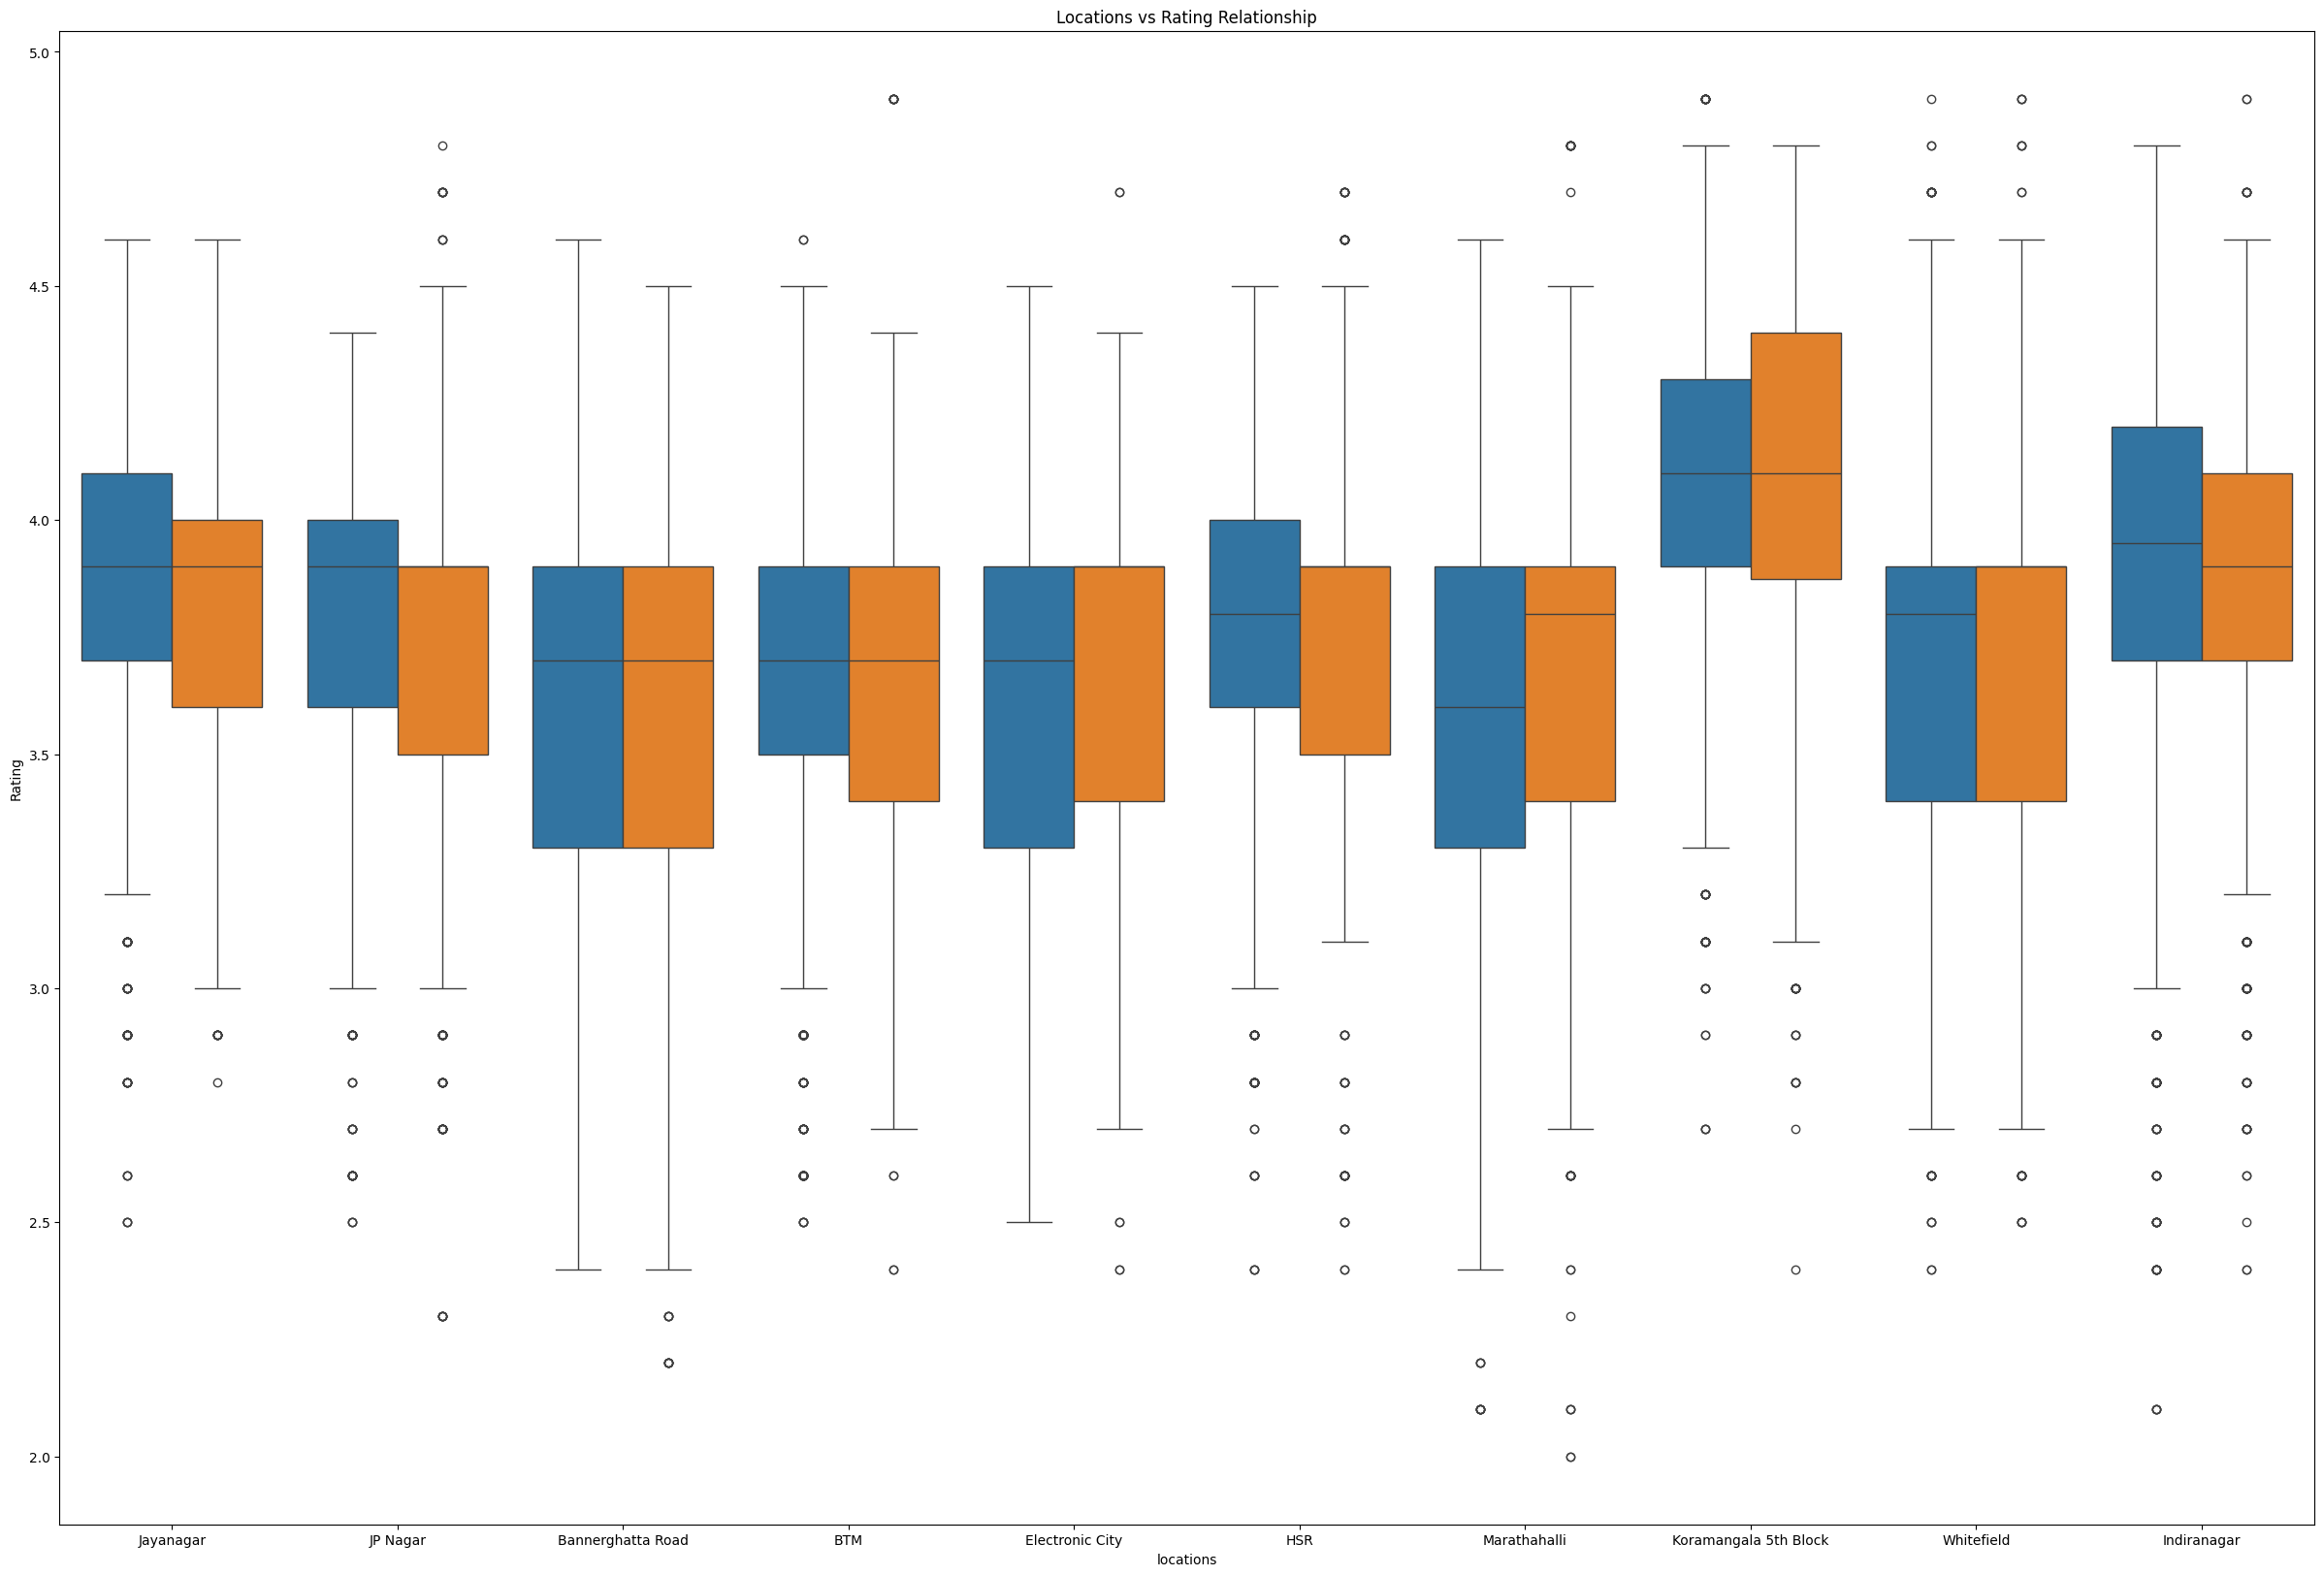

In [136]:
loc_filter= df[df['location'].isin(most_freq_location.index)]

plt.figure(figsize=(30,20))
sns.boxplot(data=loc_filter,x='location',y='rate',hue='online_order',legend=False)
plt.xlabel('locations')
plt.ylabel('Rating')
plt.title('Locations vs Rating Relationship')

### 6) Restuaremt Type Distribution

Text(0, 0.5, 'Frequency')

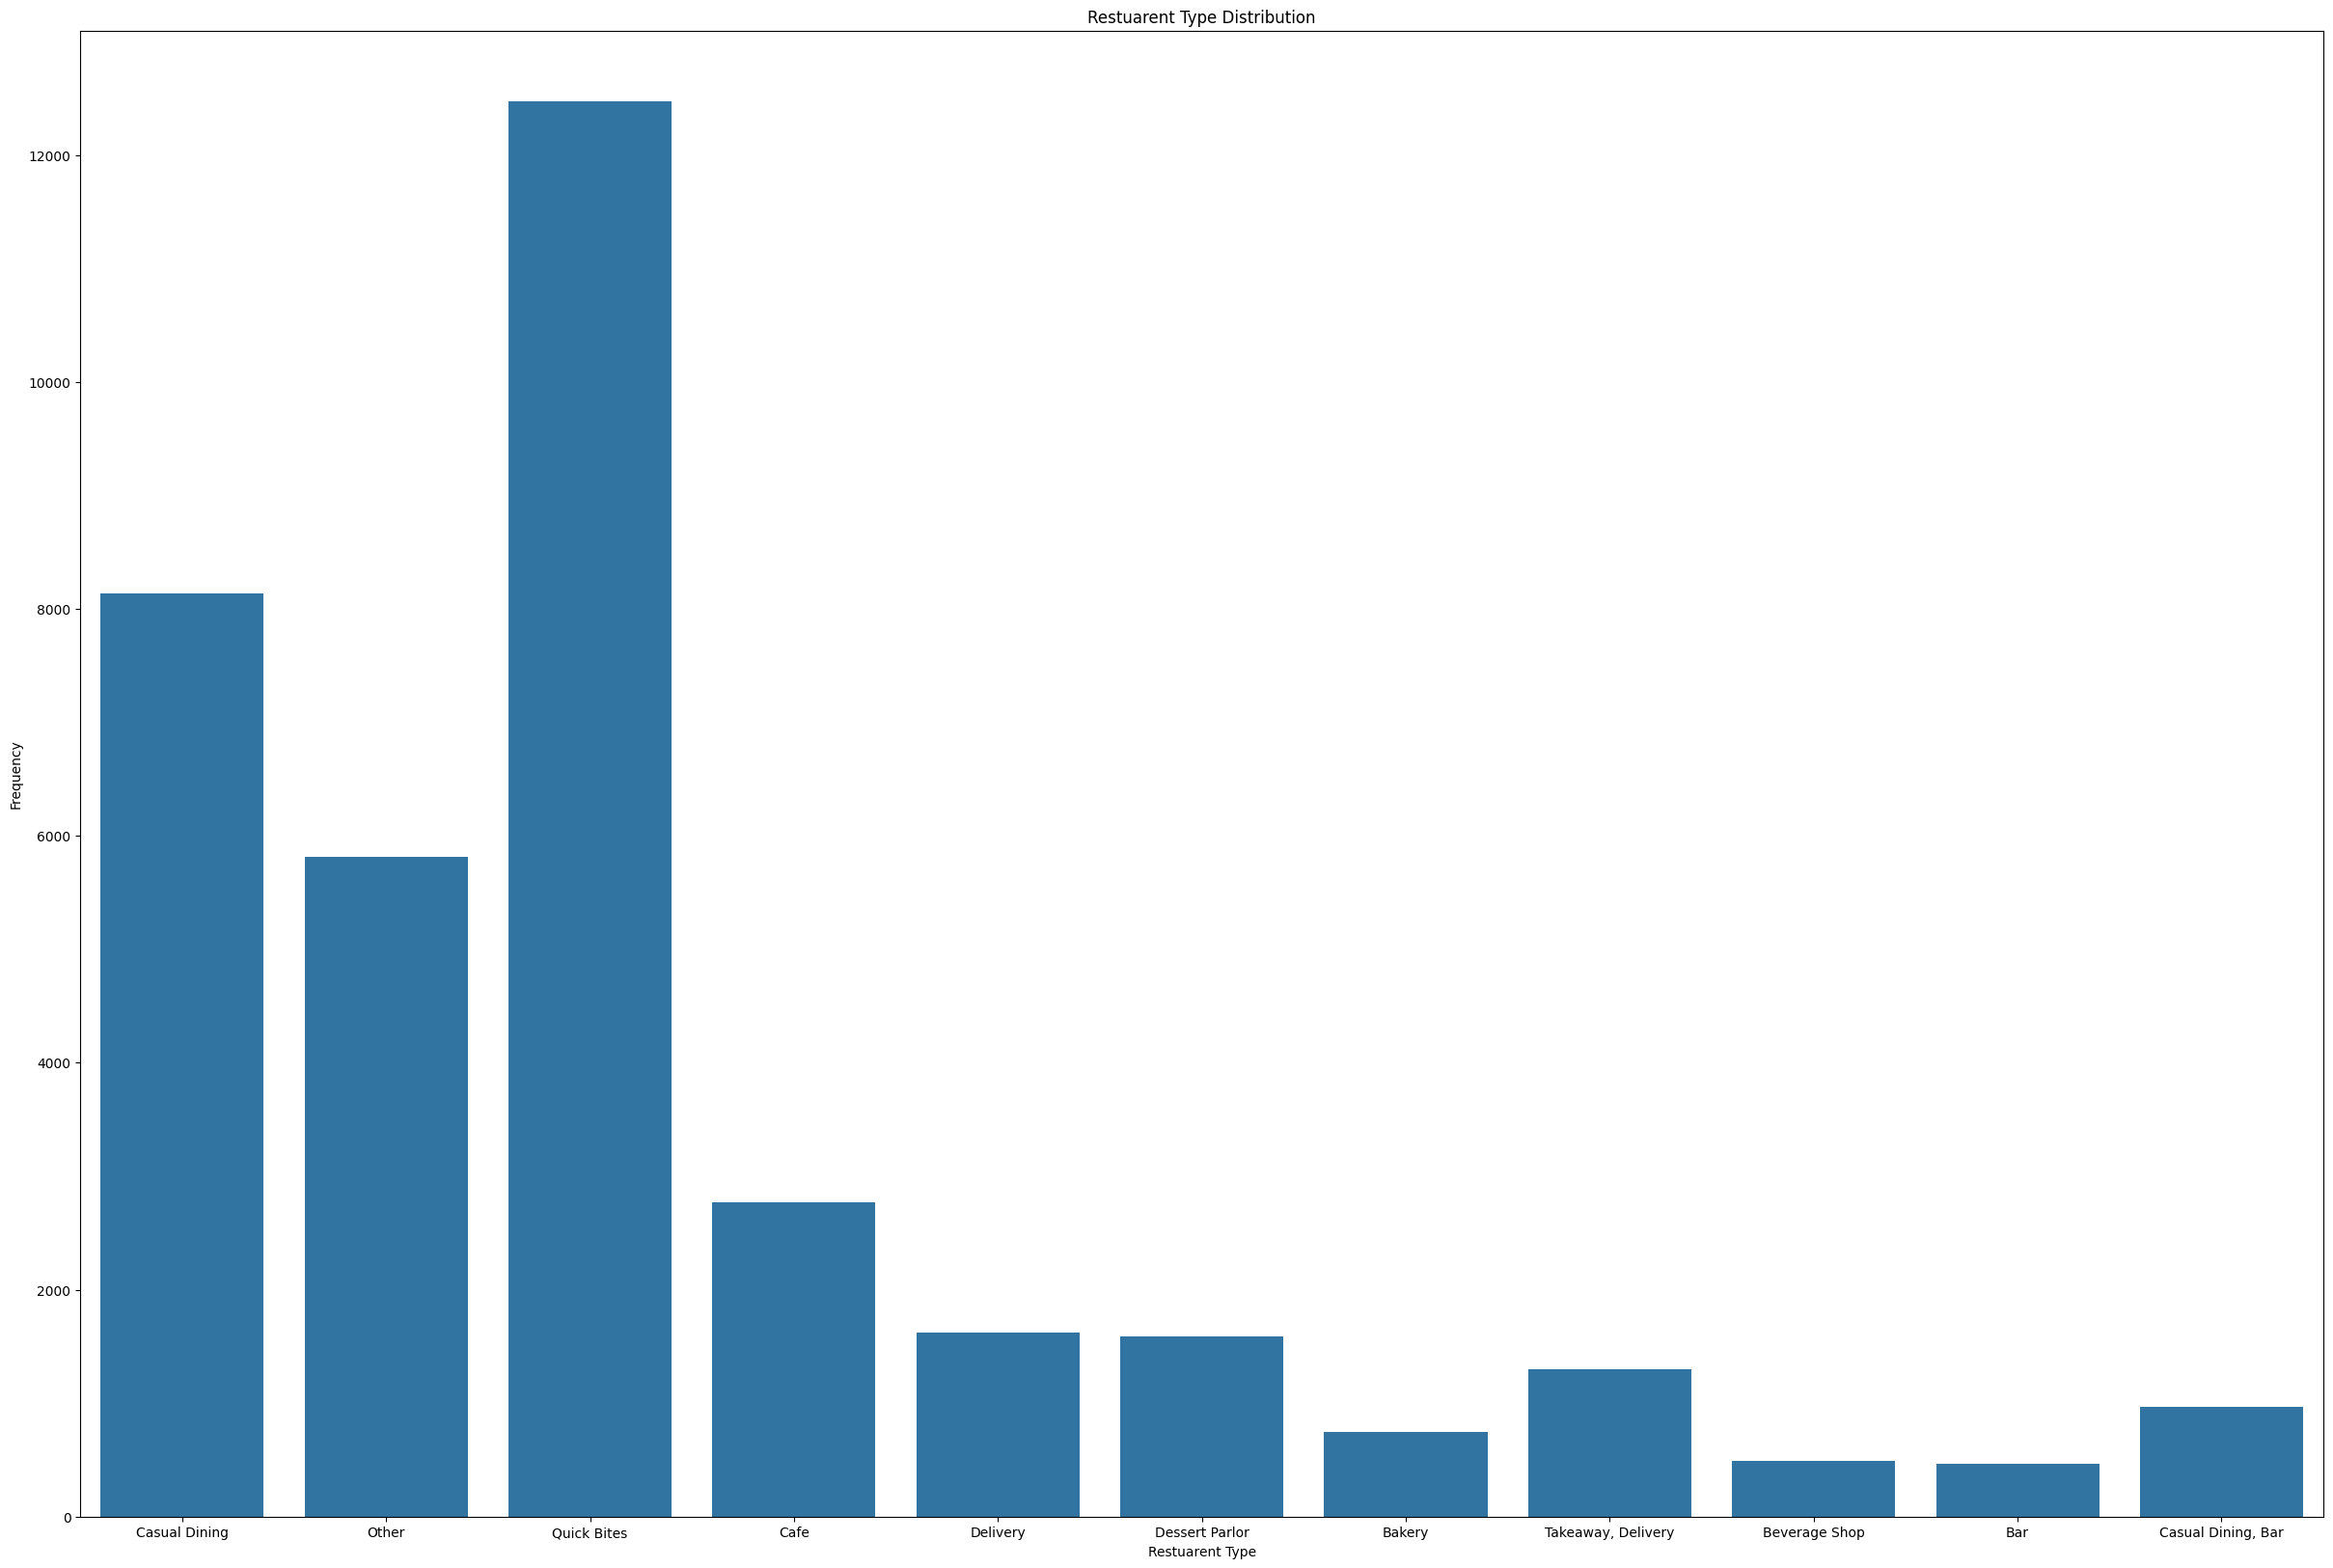

In [137]:
df['rest_type'].unique()
plt.figure(figsize=(30,20))
sns.countplot(data=df,x='rest_type')
plt.title('Restuarent Type Distribution')
plt.xlabel('Restuarent Type')
plt.ylabel('Frequency')

### 7) rating distribution Analysis
* showing the distributio of restuarent ratings

Text(0, 0.5, 'Density')

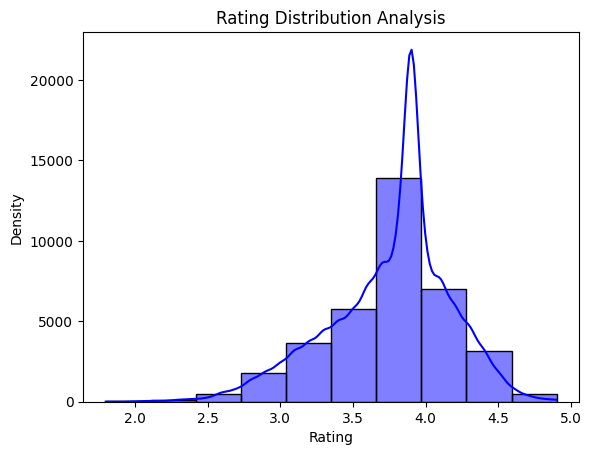

In [138]:
sns.histplot(df['rate'], kde=True, bins=10,color='blue')
plt.title('Rating Distribution Analysis')
plt.xlabel('Rating')
plt.ylabel('Density')

# It shows that most of the rating is between 3.7 and 4.0

### 8) Service Types Anlaysis
* analyzing different types of service by the restuarent

Text(0, 0.5, 'Frequency')

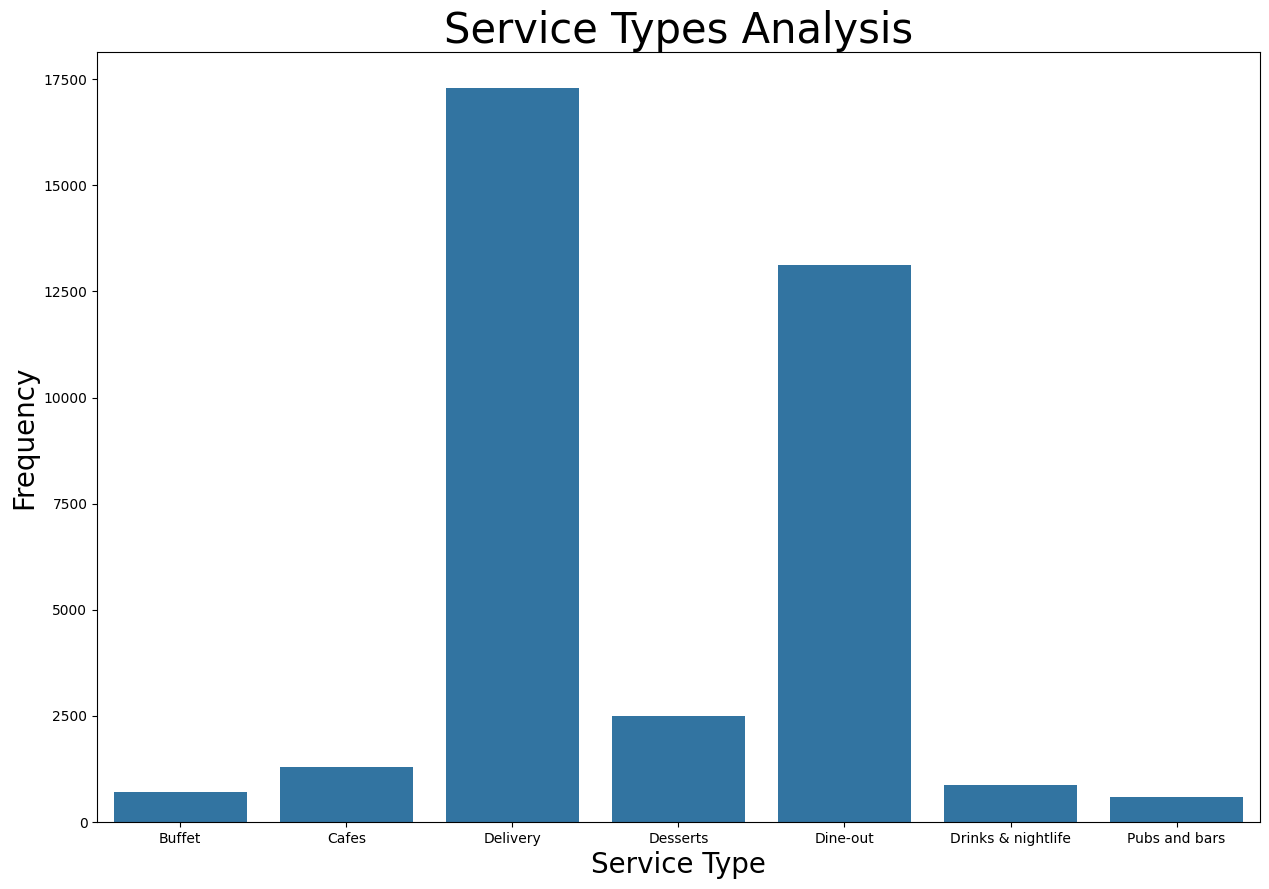

In [139]:
plt.figure(figsize=(15,10))
sns.countplot(data=df,x='type')
plt.title('Service Types Analysis',fontsize=30)
plt.xlabel('Service Type',fontsize=20)
plt.ylabel('Frequency',fontsize=20)

### 9) Service type vs Rating
* how different servive type correlate with restuaremt ratings

Text(0, 0.5, 'Rating')

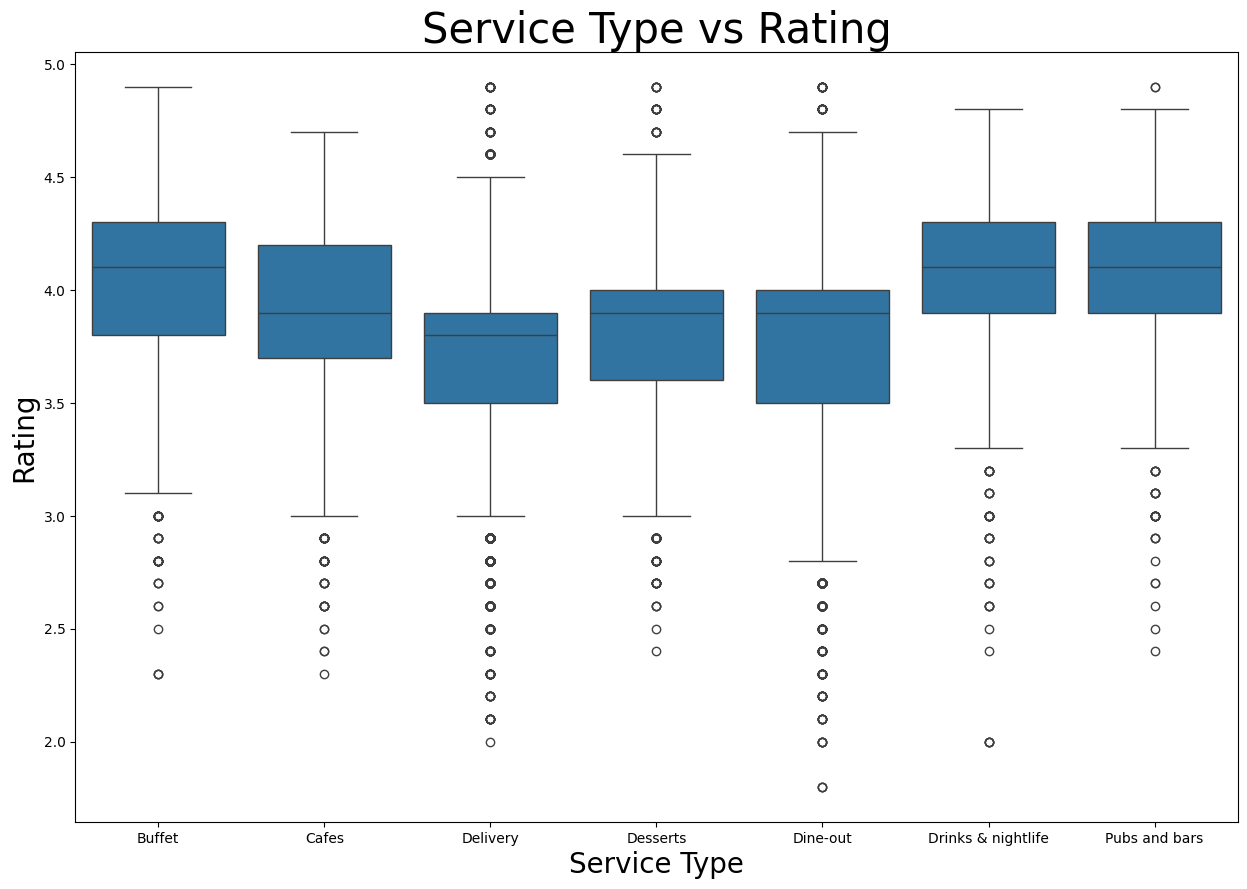

In [140]:
plt.figure(figsize=(15,10))
sns.boxplot(data=df,x='type',y='rate')
plt.title('Service Type vs Rating',fontsize=30)
plt.xlabel('Service Type',fontsize=20)
plt.ylabel('Rating',fontsize=20)

### 10) Cost distribution
* Analyzing the distributio of cost for 2 people accross all restuarent

Text(0, 0.5, 'Density')

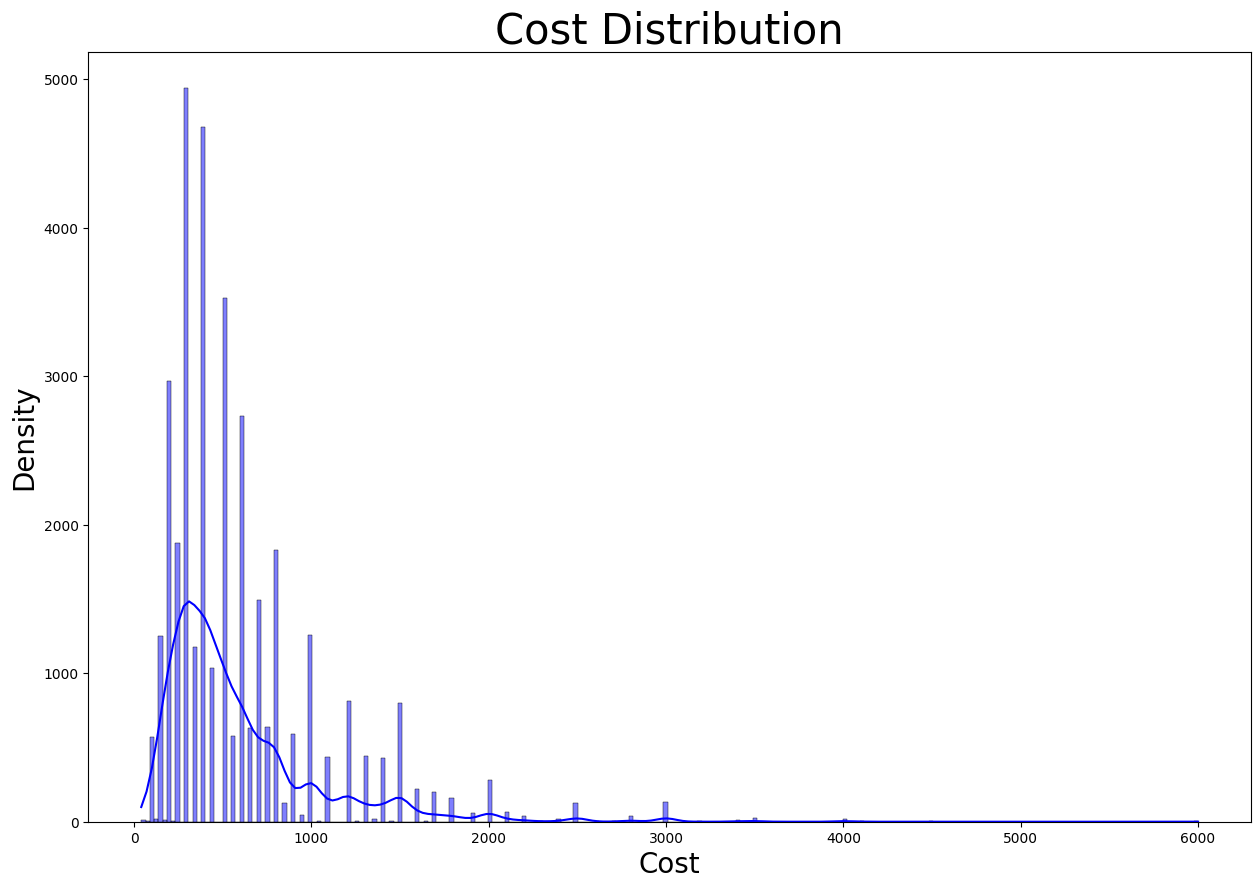

In [141]:
plt.figure(figsize=(15,10))
sns.histplot(df['CostFor2'], kde=True,color='blue')
plt.title('Cost Distribution',fontsize=30)
plt.xlabel('Cost',fontsize=20)
plt.ylabel('Density',fontsize=20)

### 11) Restuarent count by location

Text(0, 0.5, 'Location')

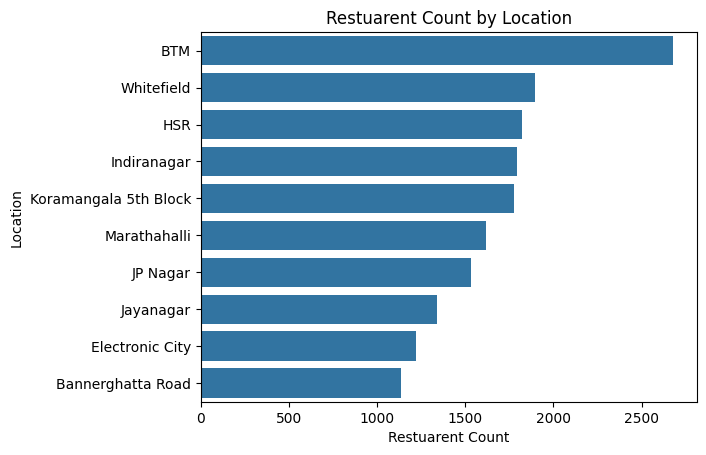

In [142]:
sns.barplot(x=most_freq_location.values , y= most_freq_location.index)
plt.title('Restuarent Count by Location')
plt.xlabel('Restuarent Count')
plt.ylabel('Location')

# Regression Analysis

In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36381 entries, 0 to 36380
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           36381 non-null  object 
 1   online_order   36381 non-null  object 
 2   book_table     36381 non-null  object 
 3   rate           36381 non-null  float64
 4   votes          36381 non-null  int64  
 5   location       36381 non-null  object 
 6   rest_type      36381 non-null  object 
 7   cuisines       36381 non-null  object 
 8   CostFor2       36381 non-null  float64
 9   type           36381 non-null  object 
 10  reviews_count  36381 non-null  int64  
dtypes: float64(2), int64(2), object(7)
memory usage: 3.1+ MB


### Data Encoding & correlation Analysis

In [144]:
le=LabelEncoder()

# applying label encoder to all the object datatype column
df=df.apply(lambda col: le.fit_transform(col) if col.dtype=='object' else col)

df.corr()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,CostFor2,type,reviews_count
name,1.000000,0.013852,0.014394,0.013788,0.013303,0.015425,0.000298,0.068411,0.034165,0.014819,0.027853
online_order,0.013852,1.000000,-0.019896,0.016576,0.027649,-0.064772,-0.022420,0.048311,-0.108866,-0.207065,0.001739
book_table,0.014394,-0.019896,1.000000,0.394867,0.412320,0.065237,-0.198624,0.128701,0.625368,0.107250,0.293180
rate,0.013788,0.016576,0.394867,1.000000,0.407479,0.060927,-0.120373,0.081645,0.339014,0.025656,0.244087
votes,0.013303,0.027649,0.412320,0.407479,1.000000,0.037655,-0.123017,0.105400,0.385691,0.051729,0.431655
location,0.015425,-0.064772,0.065237,0.060927,0.037655,1.000000,-0.041059,-0.006427,0.124982,0.051656,0.035177
rest_type,0.000298,-0.022420,-0.198624,-0.120373,-0.123017,-0.041059,1.000000,0.124953,-0.273560,0.054958,-0.100700
cuisines,0.068411,0.048311,0.128701,0.081645,0.105400,-0.006427,0.124953,1.000000,0.138251,0.062792,0.071596
CostFor2,0.034165,-0.108866,0.625368,0.339014,0.385691,0.124982,-0.273560,0.138251,1.000000,0.169467,0.285421
type,0.014819,-0.207065,0.107250,0.025656,0.051729,0.051656,0.054958,0.062792,0.169467,1.000000,0.046182


### Model Preparation

In [145]:
df.head(1)

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,CostFor2,type,reviews_count
0,3687,1,1,4.1,775,9,4,13,800.0,0,3955


In [146]:
x=df.drop(columns=df.select_dtypes(include=['object']).columns)

x=x.drop(columns=['CostFor2'])
y=df['CostFor2']

In [147]:
scaler=StandardScaler()
pf=PolynomialFeatures(degree=2)

x=pd.DataFrame(scaler.fit_transform(x),columns=x.columns)
x=pf.fit_transform(x)

In [148]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

### 1) Linear Regression Mode;

In [149]:
lr=LinearRegression()
lr.fit(x_train,y_train)


LinearRegression()

In [150]:
from sklearn.metrics import r2_score,mean_squared_error
score=lr.score(x_test,y_test)
mse_score=mean_squared_error(y_test,lr.predict(x_test))

score,mse_score

(0.5784148780742822, 81857.88375713279)

### 2) Decision Tree Regression

In [151]:
dt=DecisionTreeRegressor()
dt.fit(x_train,y_train)

DecisionTreeRegressor()

In [152]:
score=dt.score(x_test,y_test)
mse_score=mean_squared_error(y_test,dt.predict(x_test))

score,mse_score

(0.8554384867623102, 28069.063472432168)

### 3) Random Forest Reression

In [153]:
rf=RandomForestRegressor(n_estimators=200,max_features='sqrt',bootstrap=True,random_state=42)
rf.fit(x_train,y_train)

RandomForestRegressor(max_features='sqrt', n_estimators=200, random_state=42)

In [154]:
score=rf.score(x_test,y_test)
mse_score=mean_squared_error(y_test,rf.predict(x_test))

score,mse_score

(0.9086379573146237, 17739.486241337192)